# investalyze: encoding comparison (does close history predict close future?)

Different encodings (`RebaseTo100`, `LogReturns`, `zscore`, `minmax`, `demean`) define "close" differently for a k-NN search over history windows. This notebook compares them on the question that actually matters for motif-based forecasting: **when two windows have similar history under an encoding, do they also have similar future?**

For each encoding: encode the histories, find each window's nearest other window (exact `IndexFlatL2`, no speedups, no PCA), then look at the corresponding *future* segments for those same pairs. If close history reliably comes with close future, that encoding's notion of similarity is doing real predictive work; if not, it's just measuring shape resemblance with no forecasting value.

Caveat: windows overlap (`STRIDE < WINDOW_LENGTH`) and are pooled across many different instruments, so nearby windows from the same ticker's own overlapping history are the trivial, uninformative case, this is an exploratory comparison, not a controlled experiment.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2
import faiss
import matplotlib.pyplot as plt
import numpy as np
from helpers import connect_readonly

from investalyze.analysis import encodings, segments

plt.rcParams['figure.dpi'] = 130  # native pixel width must exceed the notebook panel or it won't fill it

con = connect_readonly()

## 1. Build the vectors

Load a universe, chop into windows, split history/future. Left unencoded here, each encoding below is fit and applied fresh so none of them leak into each other.

In [2]:
CLASSES = ['stocks']

HISTORY_LENGTH = 100
FUTURE_LENGTH = 10
WINDOW_LENGTH = HISTORY_LENGTH + FUTURE_LENGTH
STRIDE = 110 

tickers = segments.list_tickers(con, classes=CLASSES)
# tickers.remove('AAPL')   # curate: drop a problem ticker
# tickers += ['^DJI']      # curate: add one from another class

series = segments.get_series(con, tickers)
W, meta = segments.build_segments(series, window_length=WINDOW_LENGTH, stride=STRIDE)
history = W[:HISTORY_LENGTH, :]
future = W[HISTORY_LENGTH:, :]

print('windows', history.shape[1], 'across', meta['Ticker'].nunique(), 'tickers')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

windows 247617 across 7523 tickers


## 2. Compare encodings via k-NN

For each encoding: fit on history, transform both history and future (`LogReturns` needs its bridged `transform_future`, the others just reuse the history-fitted params). Exact `IndexFlatL2` finds each window's nearest *other* window under that encoding (K=2, self excluded); the same pair index then looks up the future distance.

In [3]:
def encode_future(name, encoder, future):
    """Apply the history-fitted encoder to `future`; LogReturns needs its bridged variant."""
    if name == 'log_returns':
        return encoder.transform_future(future)
    return encoder.transform(future)


def nearest_other(Xh):
    """Each window's nearest *other* window under Euclidean distance: (index, distance) arrays."""
    Xf32 = np.ascontiguousarray(Xh.T, dtype='float32')
    index = faiss.IndexFlatL2(Xf32.shape[1])
    index.add(Xf32)
    sq_dist, nn = index.search(Xf32, 2)  # K=2: self is always rank 0 unless tied with a duplicate
    is_self = nn == np.arange(Xf32.shape[0])[:, None]
    first_other = np.argmax(~is_self, axis=1)
    rows = np.arange(Xf32.shape[0])
    return nn[rows, first_other], np.sqrt(sq_dist[rows, first_other])


ENCODINGS = {
    'rebase_to_100': encodings.RebaseTo100(),
    'log_returns': encodings.LogReturns(),
    'zscore': encodings.zscore(),
    'minmax': encodings.minmax(),
    'demean': encodings.demean(),
}

results = {}
for name, encoder in ENCODINGS.items():
    encoder.fit(history)
    Xh = encoder.transform(history)
    Xf = encode_future(name, encoder, future)

    nn_idx, hist_dist = nearest_other(Xh)
    fut_dist = np.linalg.norm(Xf - Xf[:, nn_idx], axis=0)

    results[name] = {'Xh': Xh, 'Xf': Xf, 'nn_idx': nn_idx, 'hist_dist': hist_dist, 'fut_dist': fut_dist}
    print(f'{name}: done')

rebase_to_100: done
log_returns: done
zscore: done
minmax: done
demean: done


## 3. Closest pairs, history and future side by side

The eyeball test, per encoding: the 3 closest history pairs (one per row), history on the left, what happened next for those same two windows on the right. Each line is labeled with the ticker, its `start_idx` (pins the exact window in the raw series), and its calendar date span.

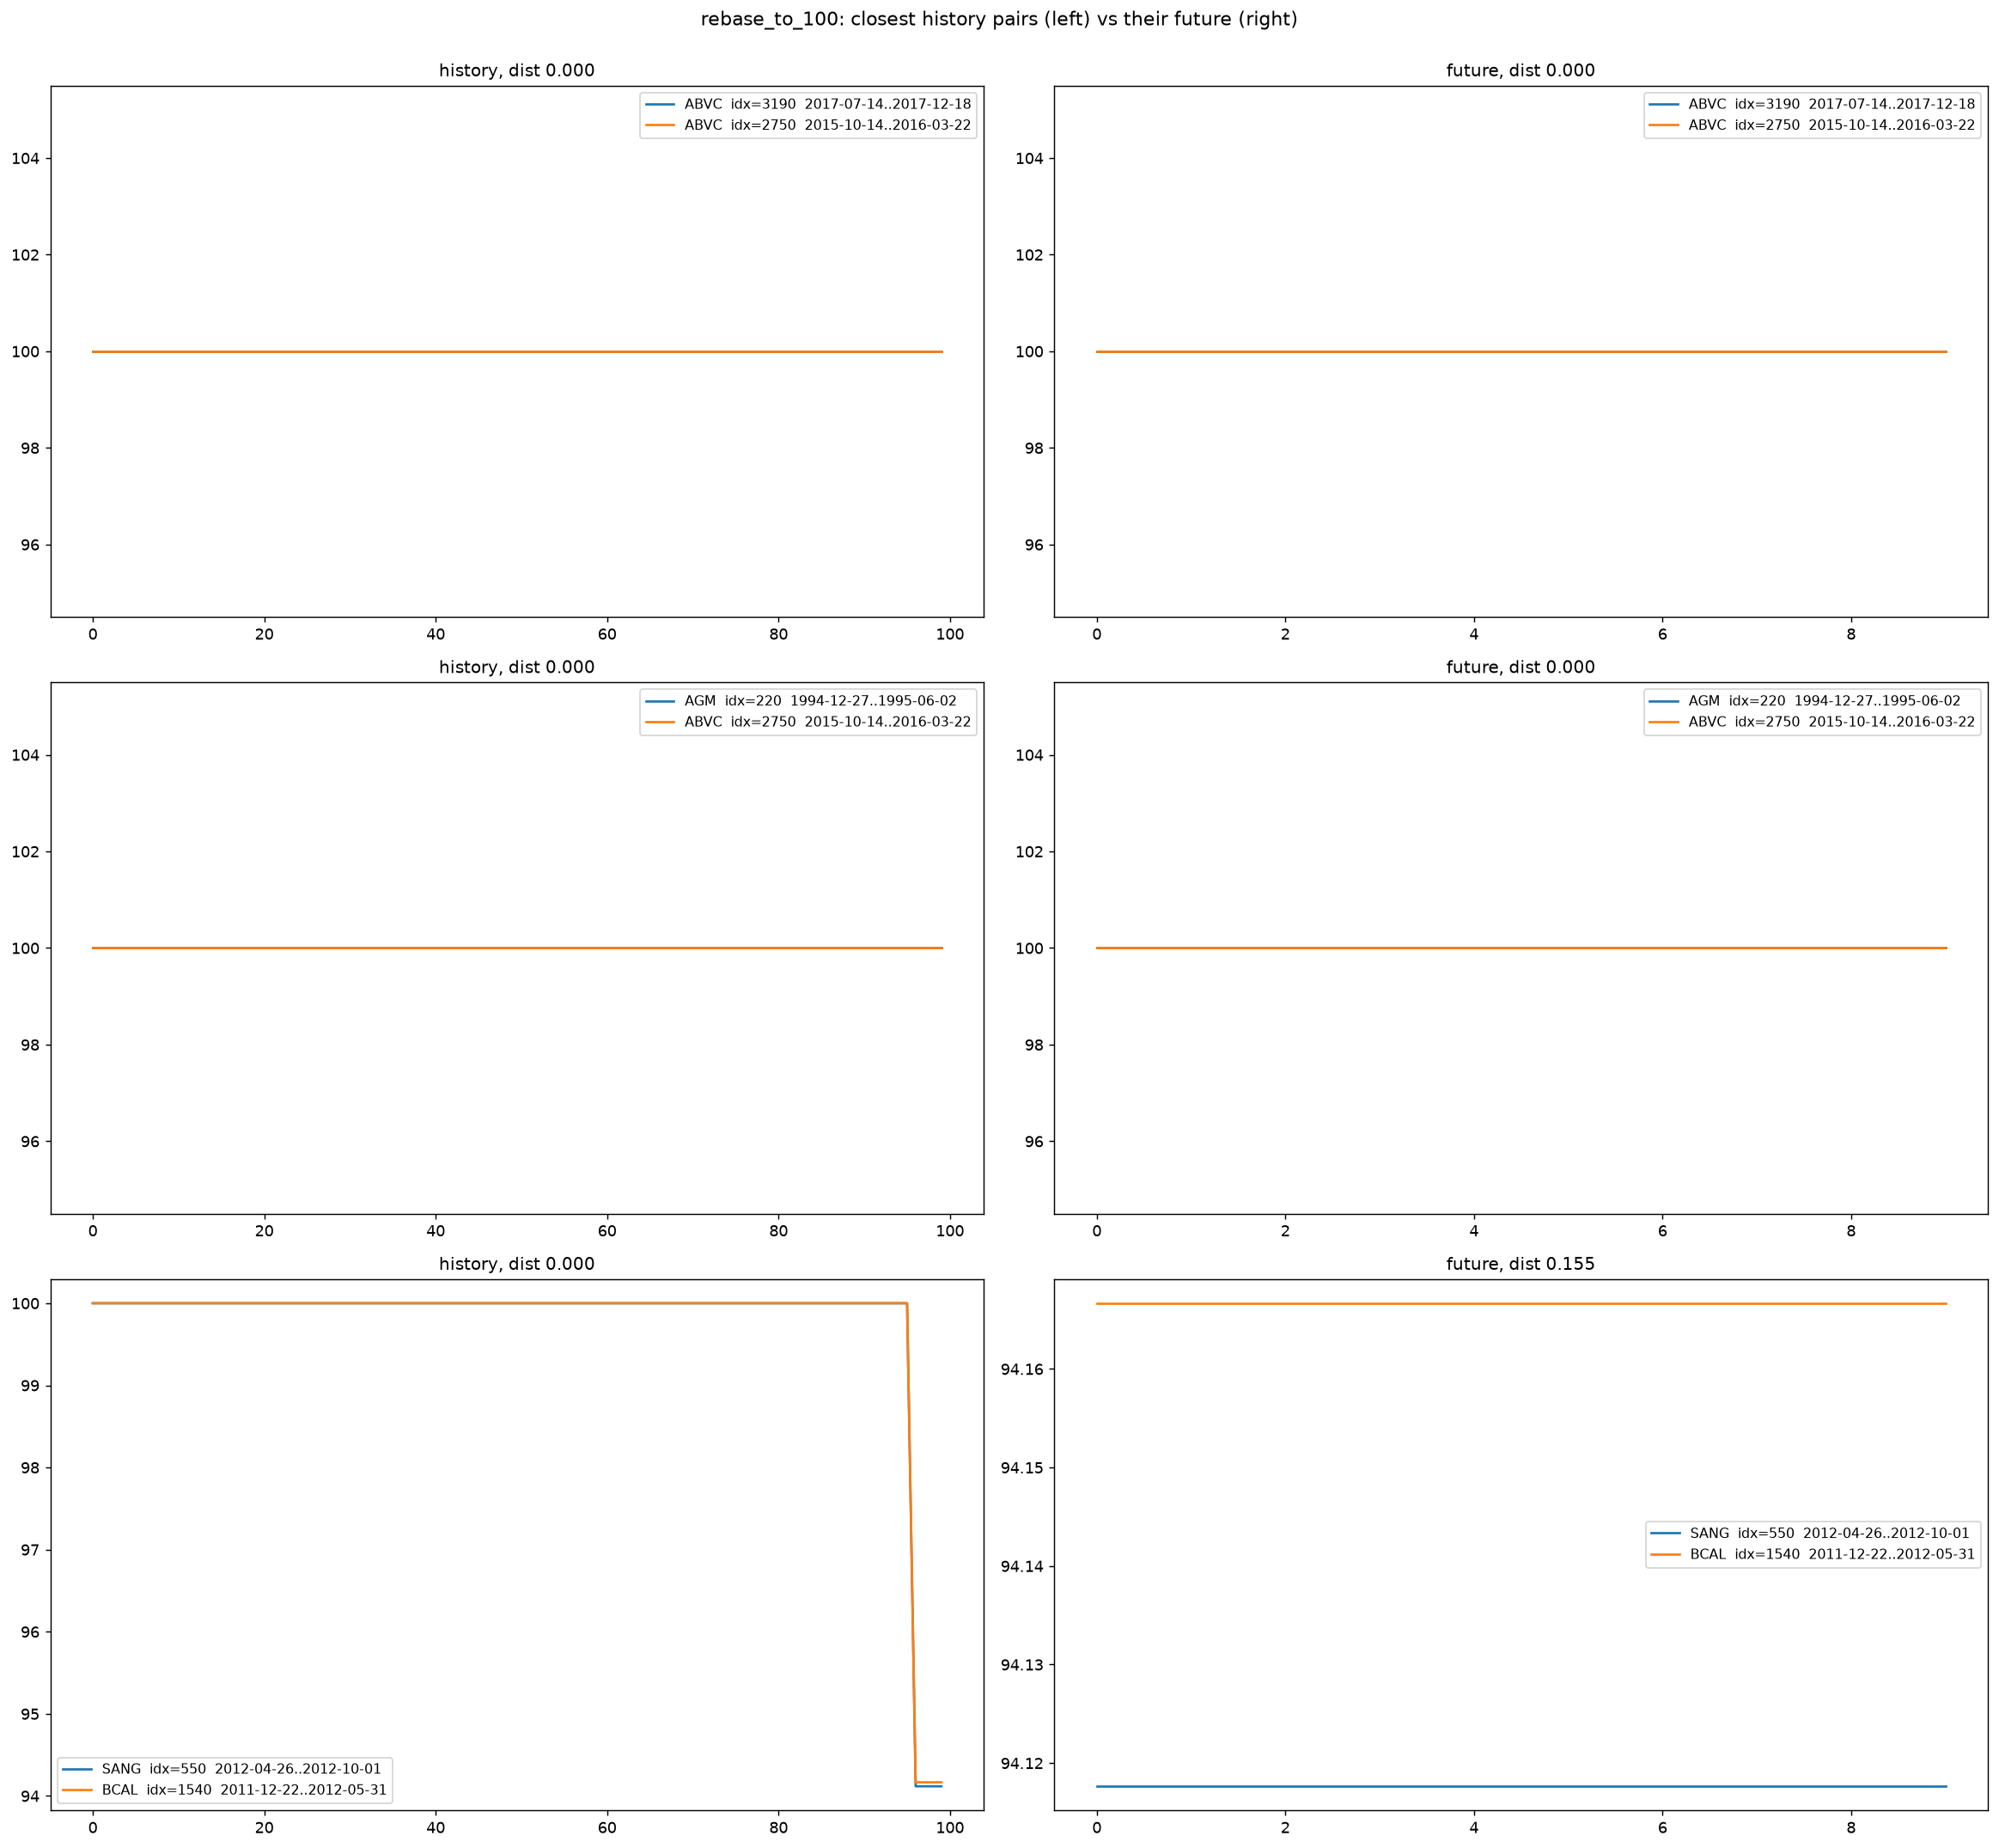

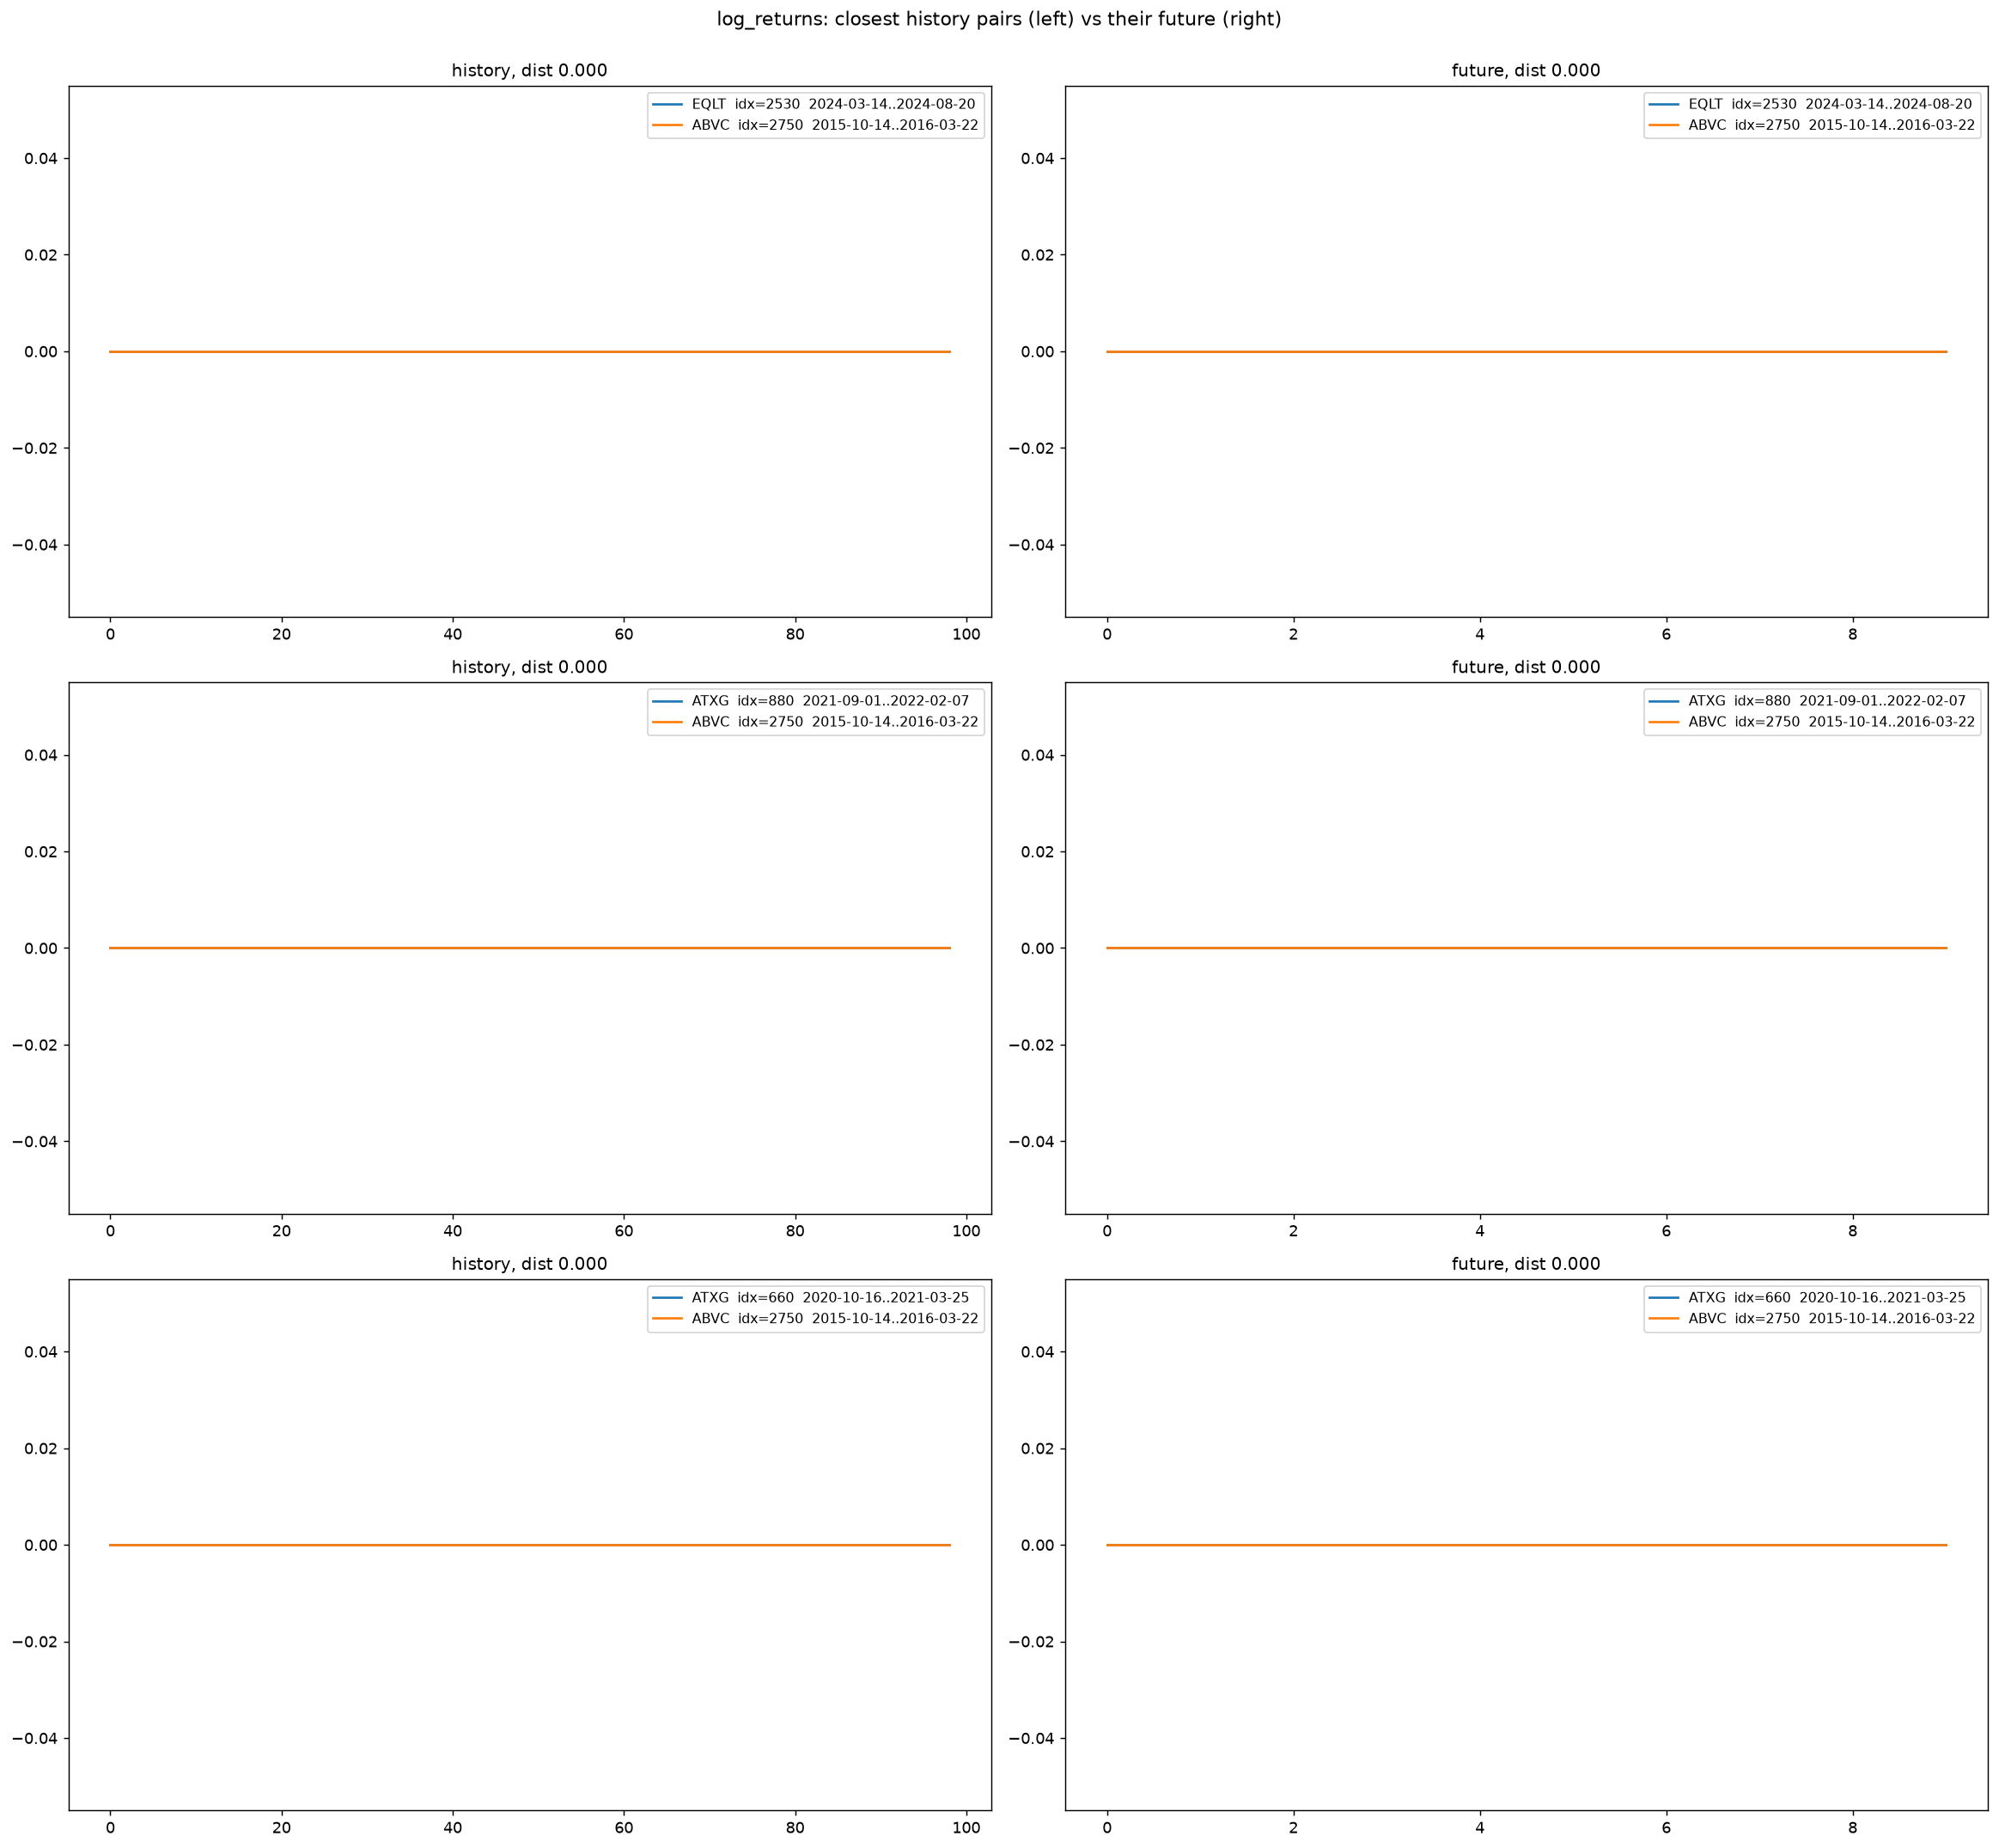

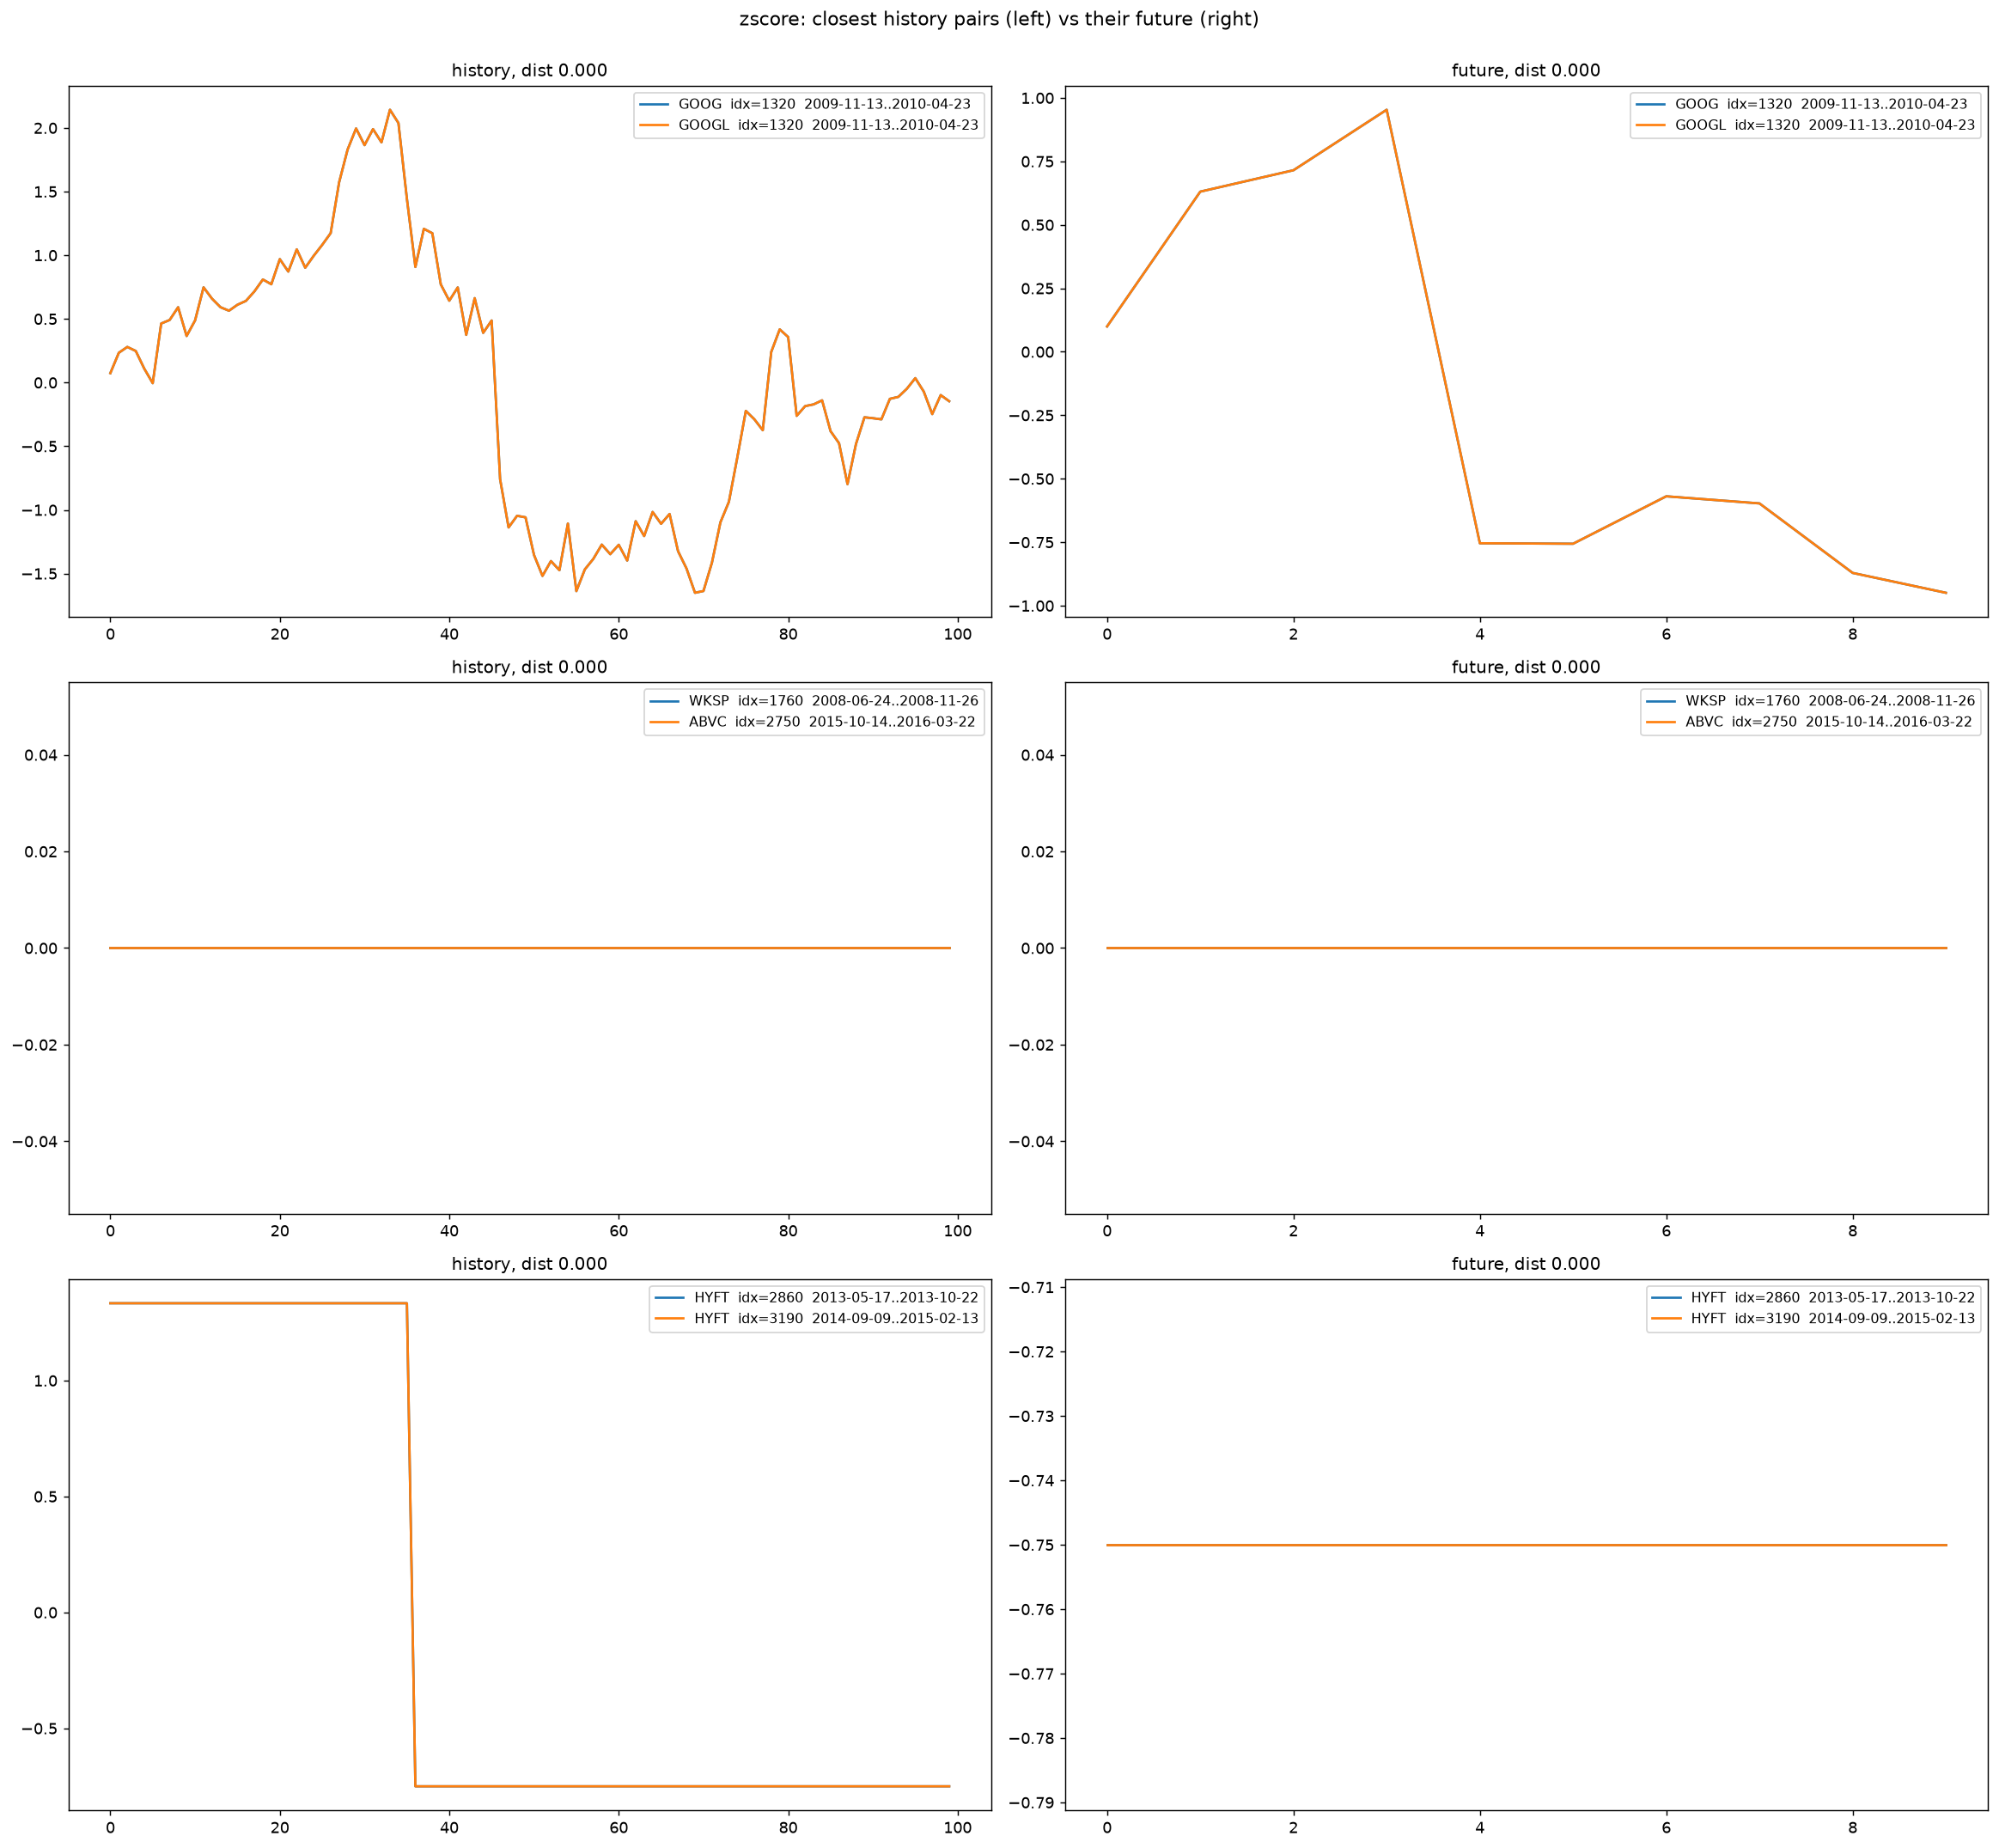

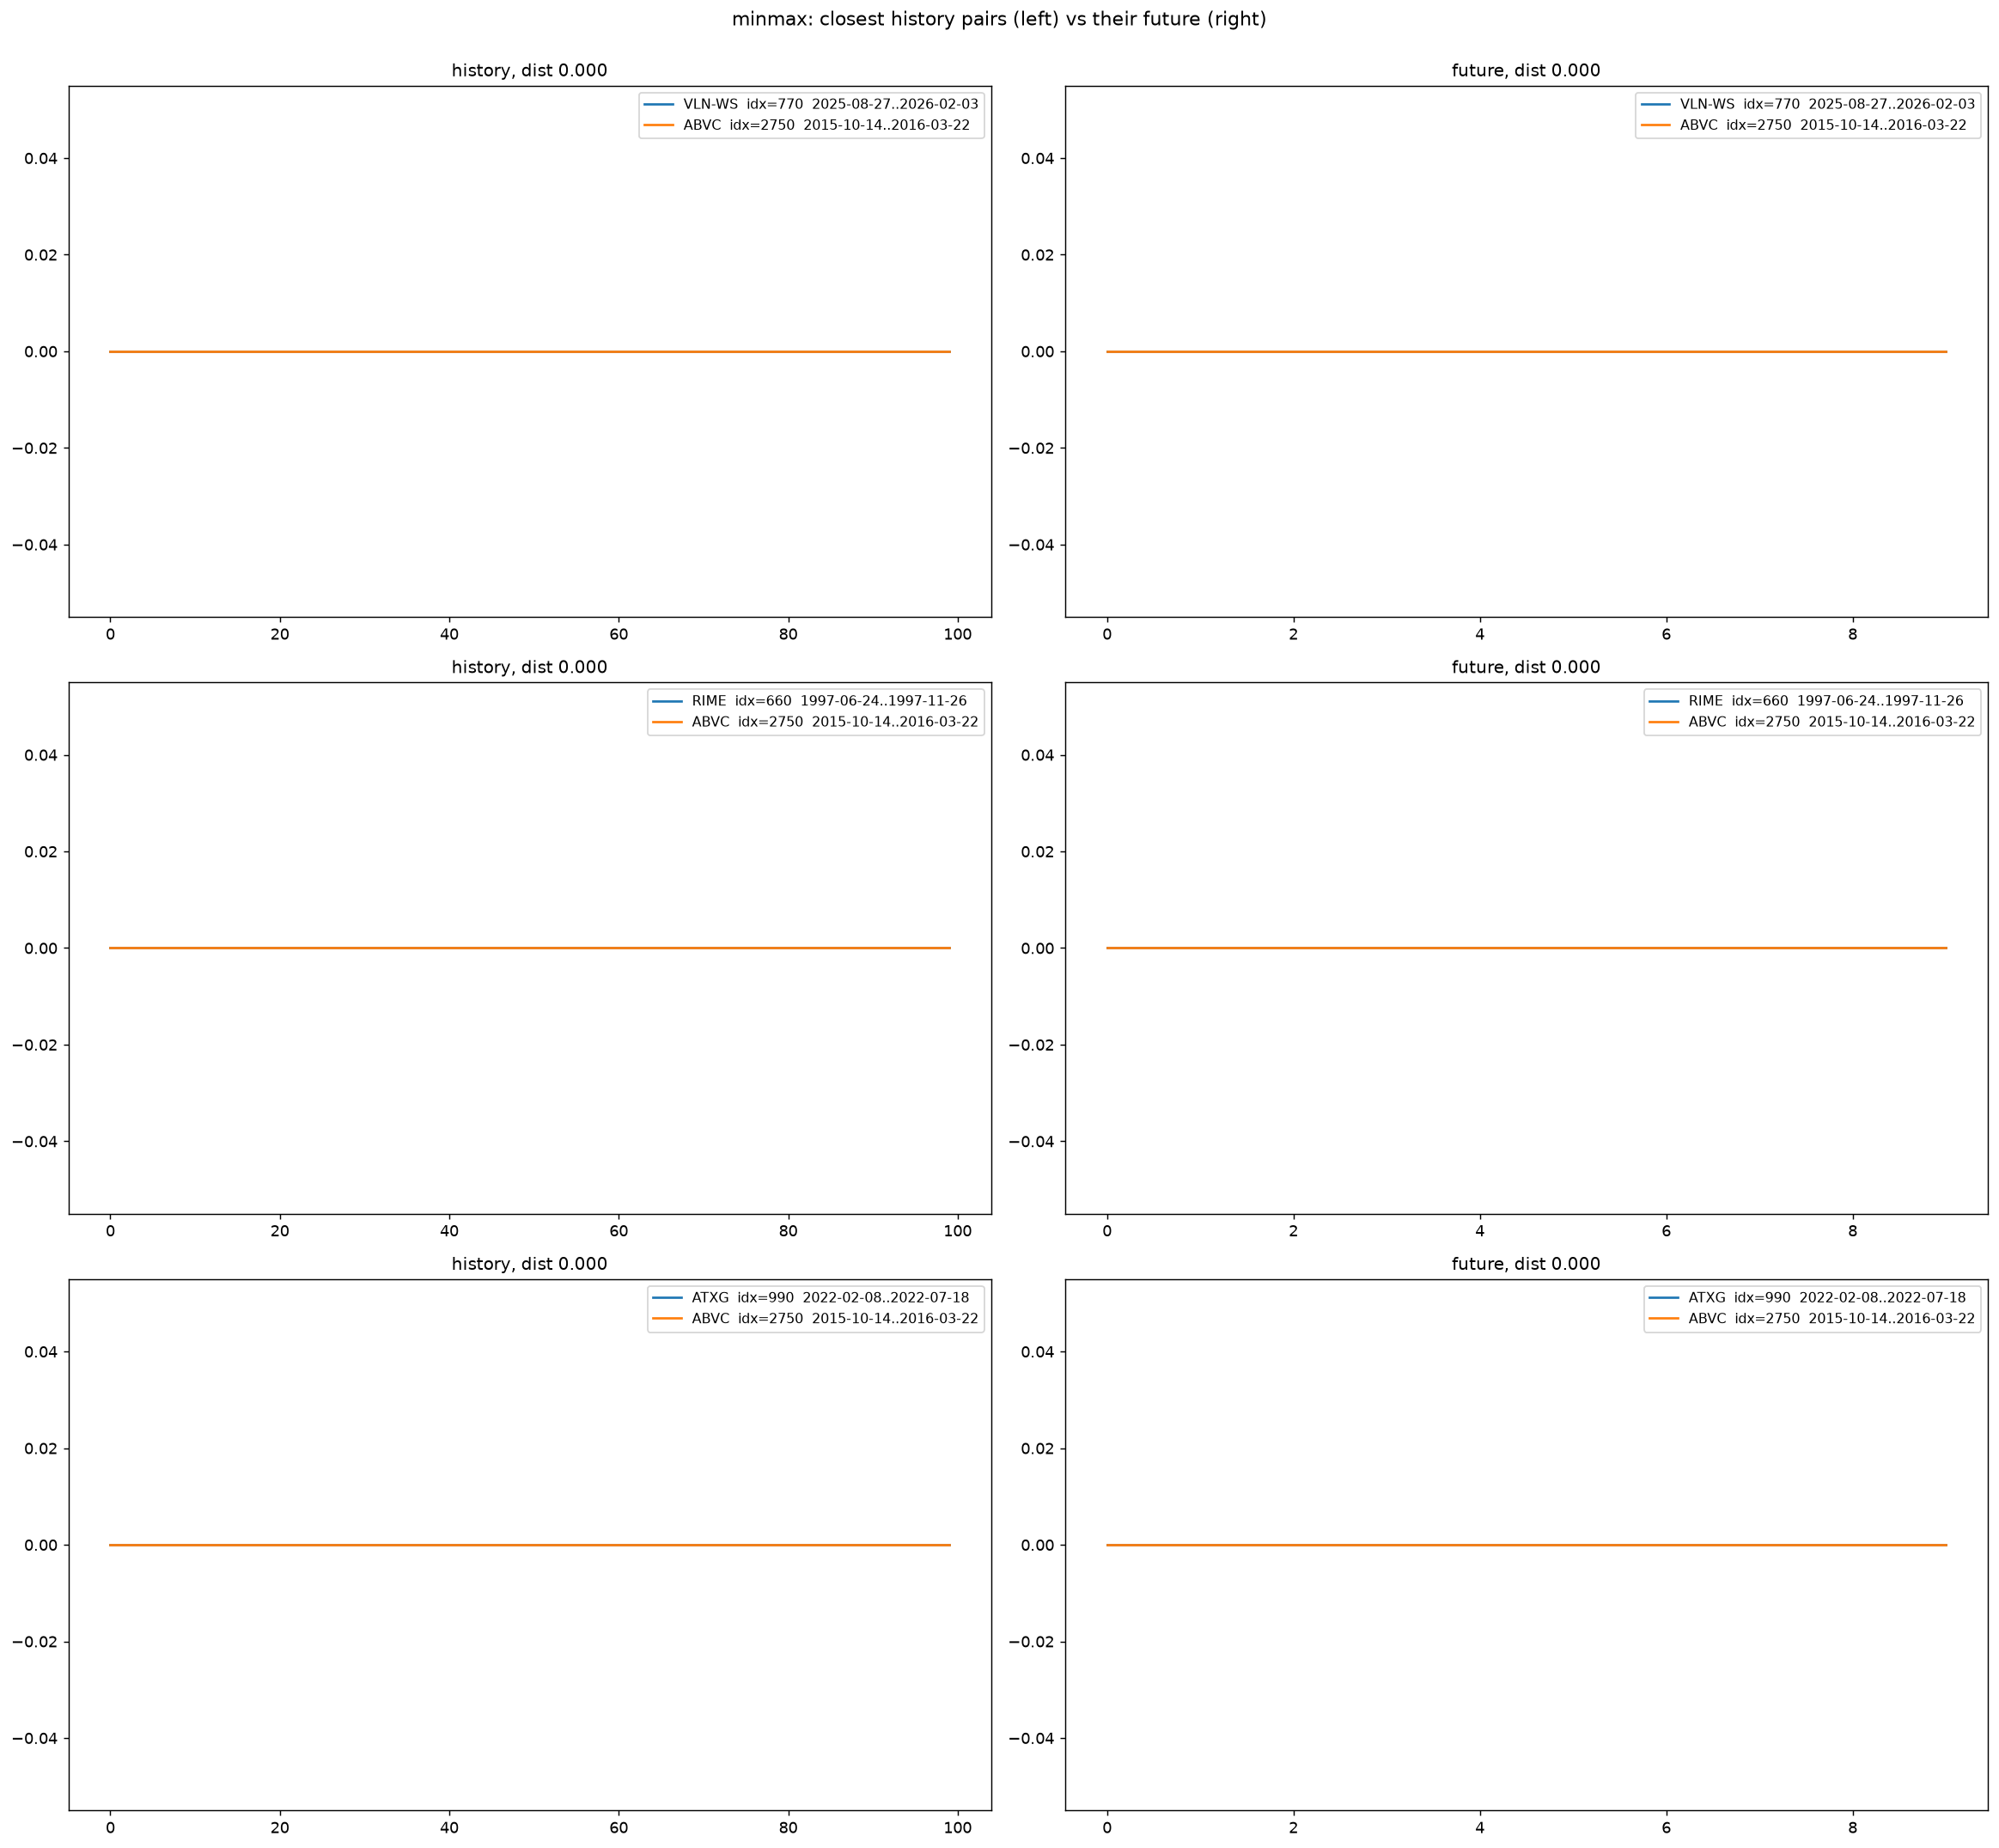

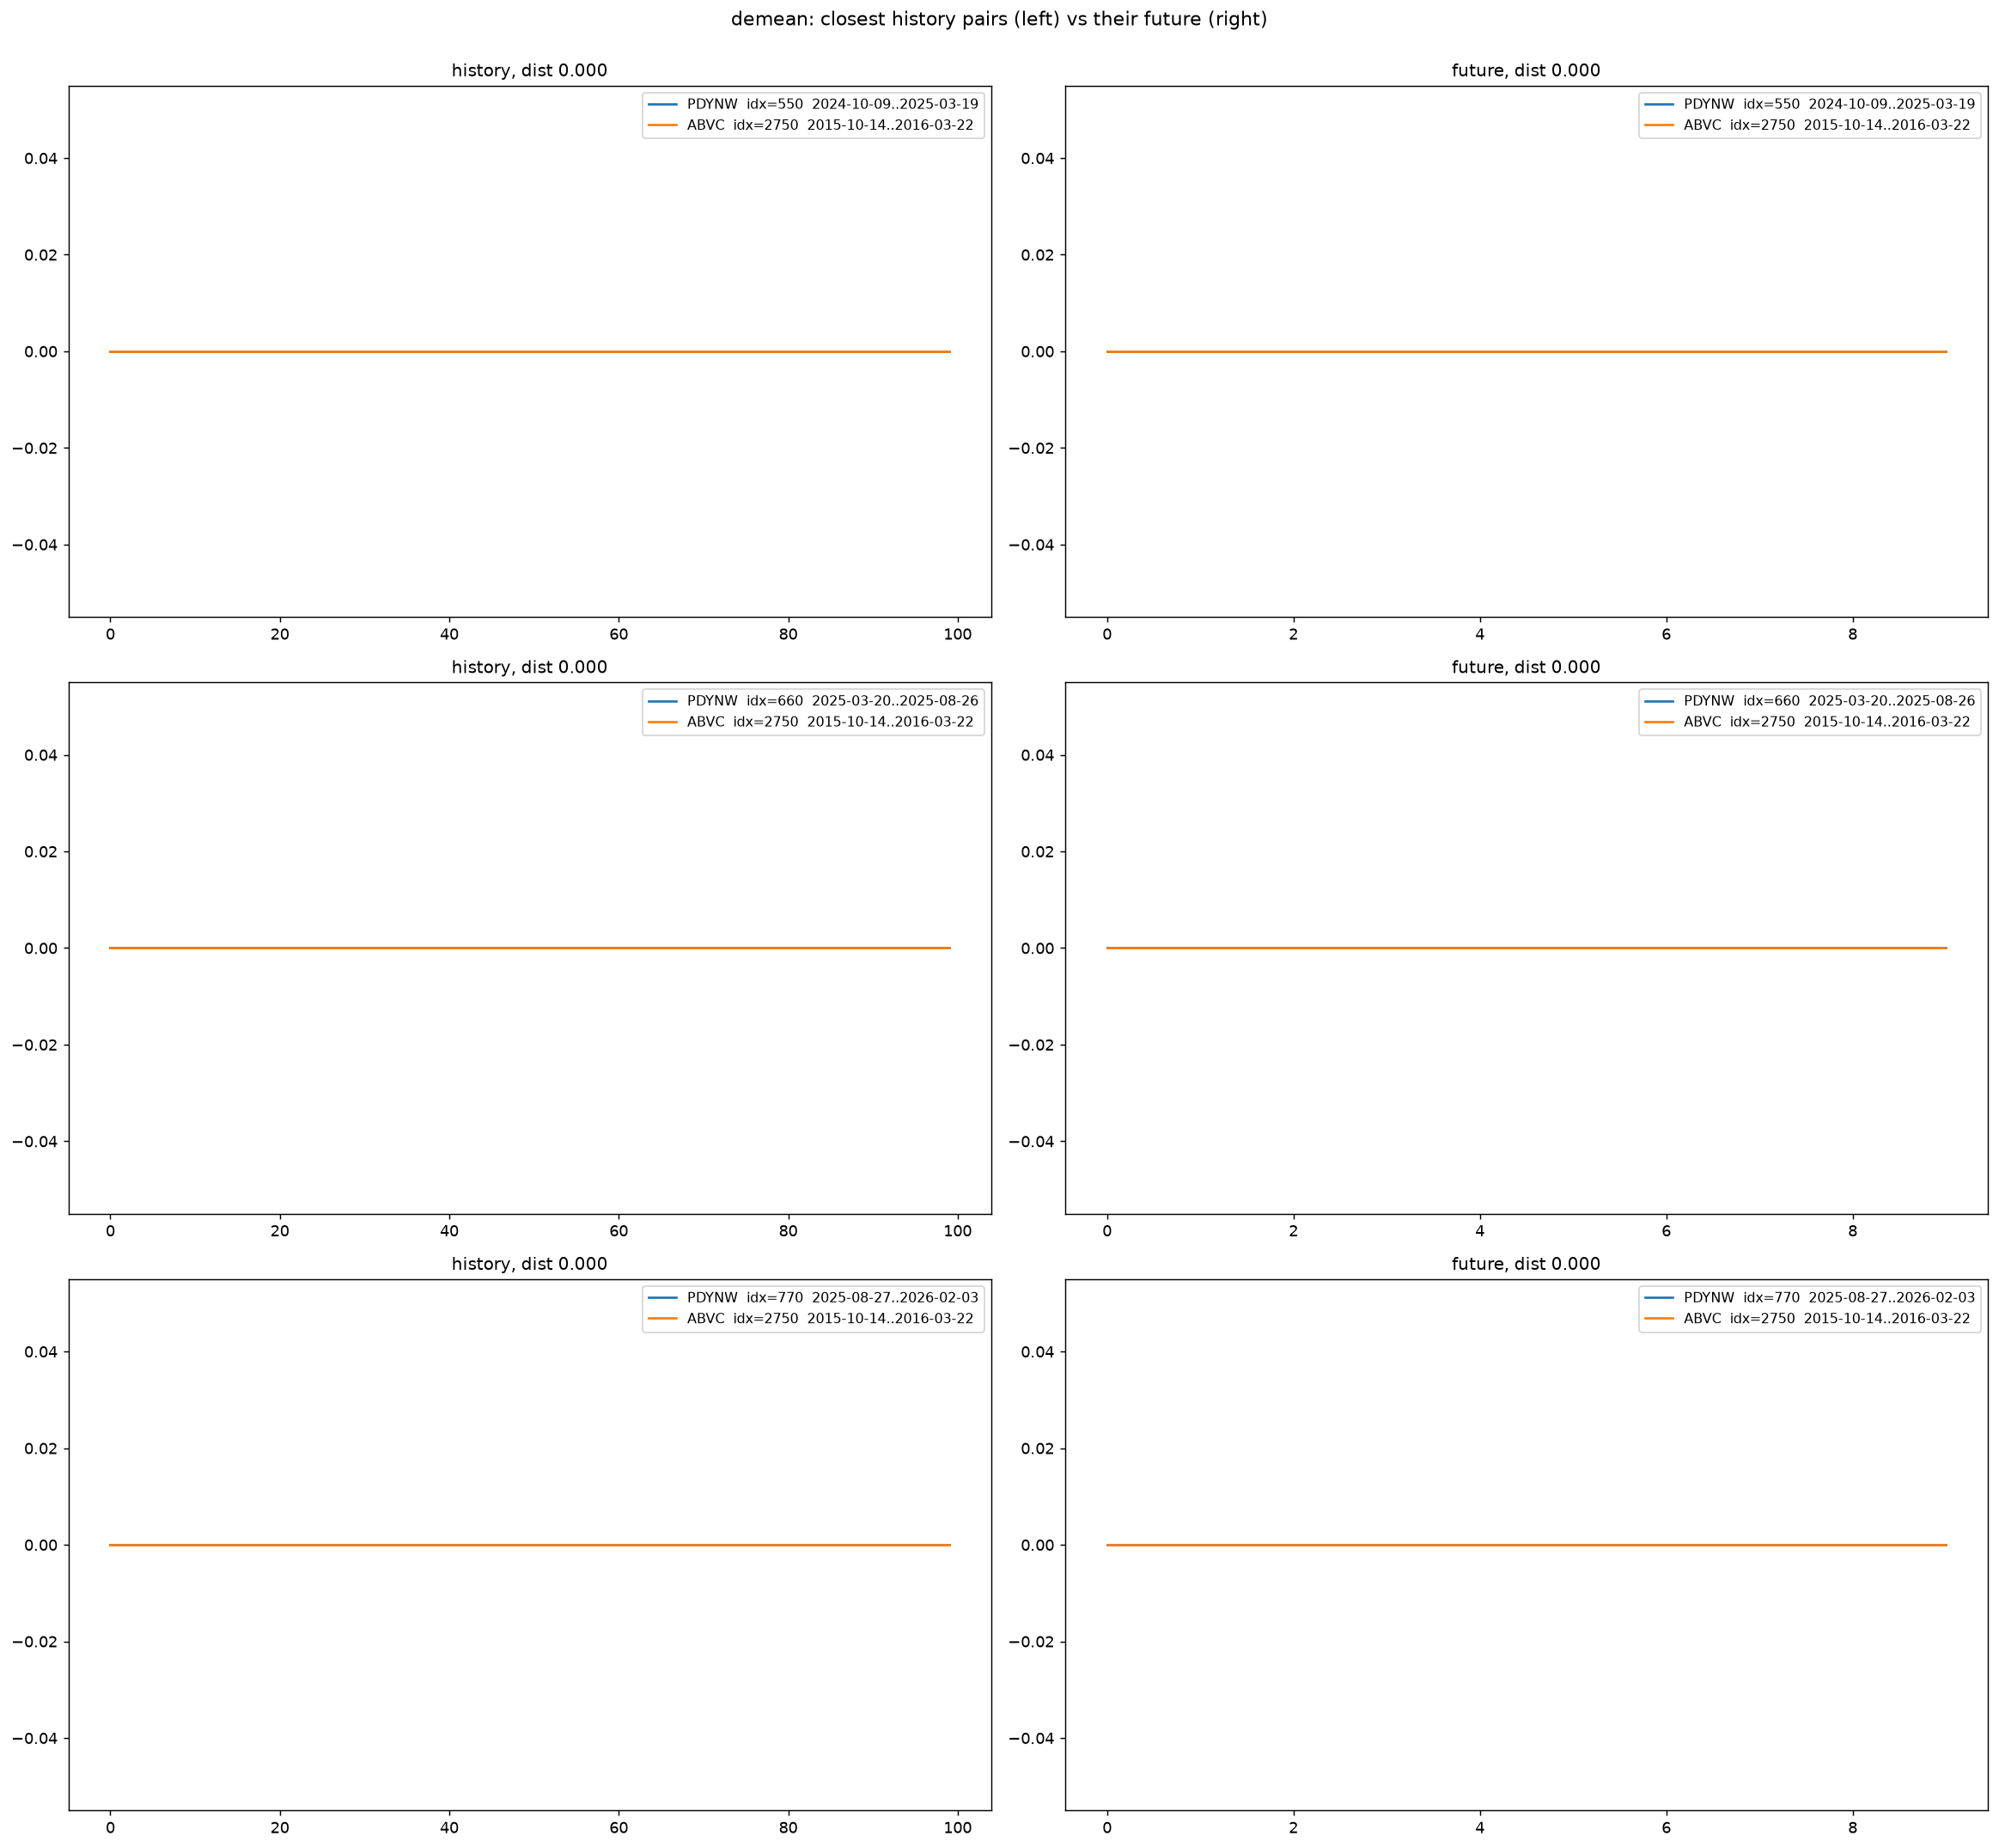

In [4]:
def closest_pairs(dist, nn_idx, n=3):
    """The n closest distinct pairs (dedupe i<->j), nearest first."""
    pairs = []
    seen = set()
    for i in np.argsort(dist):
        j = int(nn_idx[i])
        key = (min(i, j), max(i, j))
        if key in seen:
            continue
        seen.add(key)
        pairs.append((int(i), j, dist[i]))
        if len(pairs) == n:
            break
    return pairs


def window_label(idx):
    """Ticker + start_idx pins the exact window; start/end date make it human-readable."""
    m = meta.loc[idx]
    return f"{m['Ticker']}  idx={m['start_idx']}  {m['start_date']:%Y-%m-%d}..{m['end_date']:%Y-%m-%d}"


for name, r in results.items():
    xs_hist = np.arange(r['Xh'].shape[0])  # LogReturns' diff() is one row shorter than HISTORY_LENGTH
    xs_fut = np.arange(r['Xf'].shape[0])
    pairs = closest_pairs(r['hist_dist'], r['nn_idx'])
    fig, axes = plt.subplots(len(pairs), 2, figsize=(18, 5.5 * len(pairs)))
    for row, (i, j, d) in enumerate(pairs):
        ax_h, ax_f = axes[row, 0], axes[row, 1]
        for idx in (i, j):
            label = window_label(idx)
            ax_h.plot(xs_hist, r['Xh'][:, idx], label=label)
            ax_f.plot(xs_fut, r['Xf'][:, idx], label=label)
        ax_h.set_title(f'history, dist {d:.3f}', fontsize=11)
        ax_h.legend(fontsize=9)
        ax_f.set_title(f'future, dist {r["fut_dist"][i]:.3f}', fontsize=11)
        ax_f.legend(fontsize=9)
    fig.suptitle(f'{name}: closest history pairs (left) vs their future (right)', y=1.0)
    plt.tight_layout()
    plt.show()

## 4. Does close history predict close future?

Beyond the handful of closest pairs, the real question needs many pairs: for every window's nearest-history-neighbor, plot history distance against future distance. A positive relationship (low history distance -> low future distance) means the encoding's similarity is doing real predictive work; a flat cloud means it isn't.

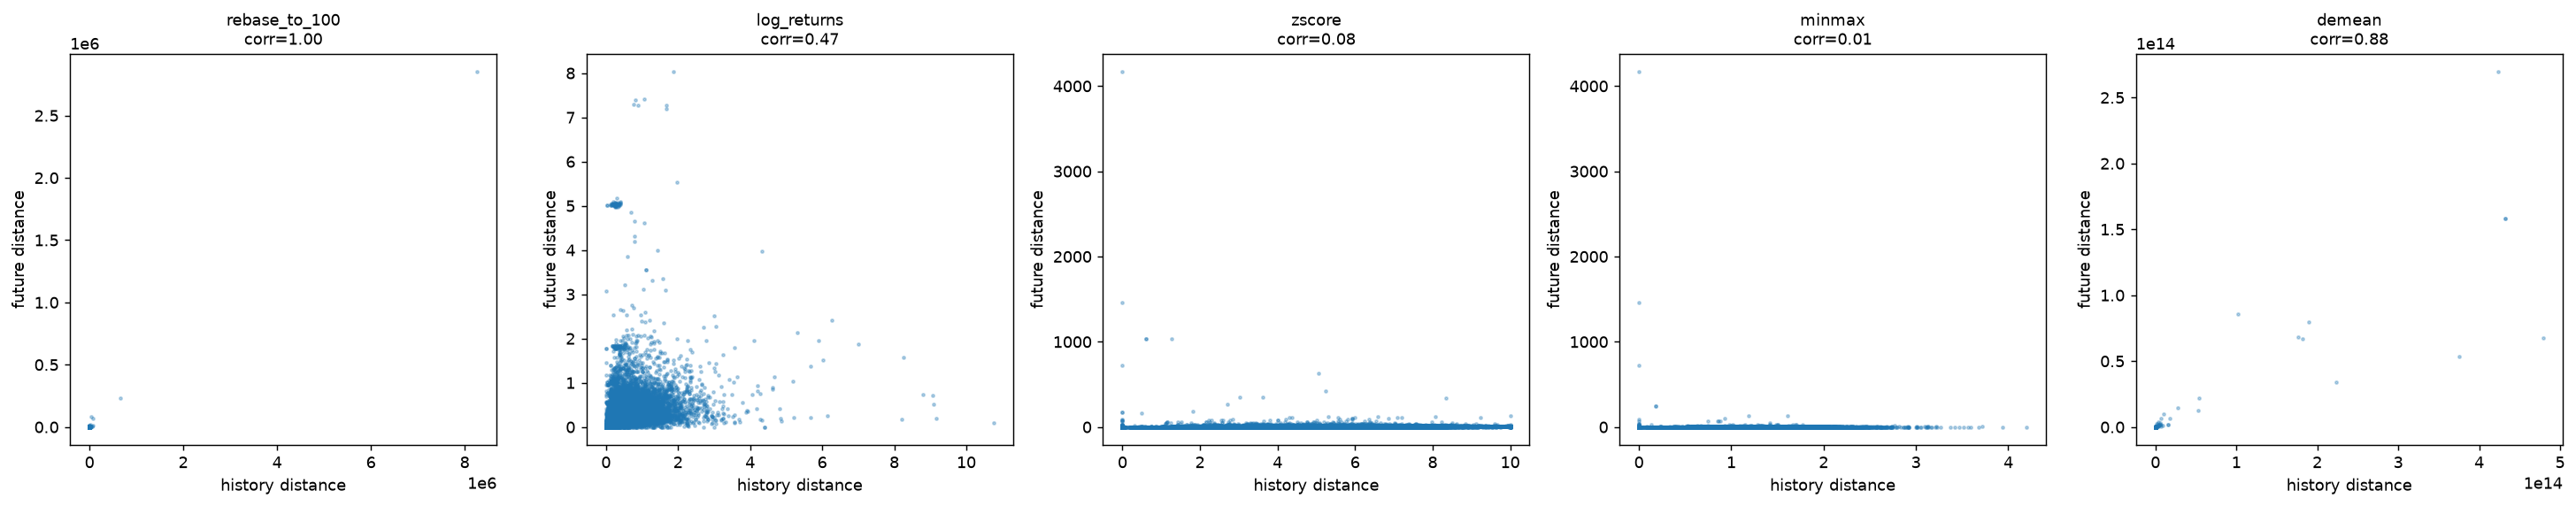

In [5]:
fig, axes = plt.subplots(1, len(results), figsize=(4.5 * len(results), 4.5))
rng = np.random.default_rng(0)
for ax, (name, r) in zip(axes, results.items()):
    n_windows = len(r['hist_dist'])
    sample = rng.choice(n_windows, size=min(300000, n_windows), replace=False)
    ax.scatter(r['hist_dist'][sample], r['fut_dist'][sample], s=3, alpha=0.3)
    corr = np.corrcoef(r['hist_dist'], r['fut_dist'])[0, 1]
    ax.set_title(f'{name}\ncorr={corr:.2f}', fontsize=10)
    ax.set_xlabel('history distance')
    ax.set_ylabel('future distance')
plt.tight_layout()
plt.show()

## 5. Robustness check: top-n neighbors

Section 4's correlation used each window's single nearest *other* window - one lucky or unlucky
neighbor can swing that result. Here each window's top-10 nearest history neighbors all
contribute a (history distance, future distance) pair, giving a correlation built on 10x more
data per encoding.

In [ ]:
def nearest_n_others(Xh, n):
    """Each window's n nearest *other* windows under Euclidean distance: (indices, distances) arrays, shape (n_windows, n)."""
    Xf32 = np.ascontiguousarray(Xh.T, dtype='float32')
    index = faiss.IndexFlatL2(Xf32.shape[1])
    index.add(Xf32)
    sq_dist, nn = index.search(Xf32, n + 1)  # +1: self is usually among the results
    n_windows = Xf32.shape[0]
    rows = np.arange(n_windows)
    is_self = nn == rows[:, None]
    # stable sort puts non-self entries first, preserving ascending-distance order, so the first n
    # columns are the n nearest *other* windows even when a duplicate-distance cluster (e.g. flat
    # or delisted-ticker windows with identical values) is larger than n + 1 and pushes self out
    order = np.argsort(is_self, axis=1, kind='stable')
    nn_sorted = np.take_along_axis(nn, order, axis=1)
    dist_sorted = np.take_along_axis(sq_dist, order, axis=1)
    return nn_sorted[:, :n], np.sqrt(dist_sorted[:, :n])


N_NEIGHBORS = 10

fig, axes = plt.subplots(1, len(results), figsize=(4.5 * len(results), 4.5))
rng = np.random.default_rng(0)
for ax, (name, r) in zip(axes, results.items()):
    nn_idx_n, hist_dist_n = nearest_n_others(r['Xh'], N_NEIGHBORS)
    Xf = r['Xf']
    fut_dist_n = np.linalg.norm(Xf[:, nn_idx_n] - Xf[:, :, None], axis=0)

    hist_dist_flat = hist_dist_n.ravel()
    fut_dist_flat = fut_dist_n.ravel()

    n_points = len(hist_dist_flat)
    sample = rng.choice(n_points, size=min(300000, n_points), replace=False)
    ax.scatter(hist_dist_flat[sample], fut_dist_flat[sample], s=3, alpha=0.3)
    corr = np.corrcoef(hist_dist_flat, fut_dist_flat)[0, 1]
    ax.set_title(f'{name}\ncorr={corr:.2f}', fontsize=10)
    ax.set_xlabel('history distance')
    ax.set_ylabel('future distance')
plt.tight_layout()
plt.show()